# High-Accuracy LSTM for Fault Prediction (c499) — A100 config



In [1]:
import sys, platform, subprocess, time

try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
    cpu_logical = psutil.cpu_count(logical=True)
except Exception:
    ram_gb = None; cpu_logical = None

print("=== Environment ===")
print("Python:", sys.version.replace(chr(10), ' '))
print("Platform:", platform.platform())
print("CPU logical cores:", cpu_logical)
print("RAM (GB):", None if ram_gb is None else round(ram_gb, 2))

try:
    import torch
    print(chr(10) + "=== PyTorch ===")
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2))
    else:
        print(chr(10) + "WARNING: no GPU. Runtime > Change runtime type > T4 GPU.")
except Exception as e:
    print(chr(10) + "PyTorch not available:", e)

print(chr(10) + "=== nvidia-smi ===")
try:
    print(subprocess.check_output(["nvidia-smi"], text=True).splitlines()[0])
except Exception as e:
    print("nvidia-smi not available:", e)


=== Environment ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU logical cores: 12
RAM (GB): 89.63

=== PyTorch ===
torch: 2.11.0+cu128
cuda available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM (GB): 42.41

=== nvidia-smi ===
Fri Jul 17 21:37:03 2026       


In [2]:
# ===== Timing + Peak RAM/VRAM helper (identical to your ANN/LSTM notebooks) =====
import os, time, threading, subprocess

try:
    import psutil
    _ps_proc = psutil.Process(os.getpid())
except Exception:
    psutil = None; _ps_proc = None

def rss_mb():
    if _ps_proc is None: return None
    return _ps_proc.memory_info().rss / (1024**2)

def gpu_vram_mb():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"], text=True)
        return float(out.strip().splitlines()[0])
    except Exception:
        return None

class PeakMonitor:
    def __init__(self, interval_sec=0.5):
        self.interval = interval_sec; self._stop = False
        self.peak_rss = 0.0; self.peak_vram = 0.0; self._thread = None
    def _run(self):
        while not self._stop:
            r = rss_mb()
            if r is not None: self.peak_rss = max(self.peak_rss, float(r))
            v = gpu_vram_mb()
            if v is not None: self.peak_vram = max(self.peak_vram, float(v))
            time.sleep(self.interval)
    def start(self):
        self._stop = False; self.peak_rss = 0.0; self.peak_vram = 0.0
        self._thread = threading.Thread(target=self._run, daemon=True); self._thread.start()
    def stop(self):
        self._stop = True
        if self._thread is not None: self._thread.join(timeout=2)
        return self.peak_rss, self.peak_vram


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Same path convention as your notebooks.
test_path = '/content/drive/My Drive/circuits/c499.test'

MAX_EXPAND    = 3          # don't-care expansion, matches your baseline
BITS_PER_STEP = 1          # 73 bits -> 73-step sequence (fine-grained, like the c1355/c1908 runs)
MAX_SAMPLES   = None       # all 72,602 rows
HIDDEN_SIZE   = 384
EPOCHS        = 60
LR            = 1e-3       # stable regime; divergence guard armed
BATCH_SIZE    = 512


In [6]:
import itertools, random
from collections import defaultdict
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn, torch.optim as optim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

_COMBOS3 = np.array(list(itertools.product([0, 1], repeat=3)), dtype=np.uint8)

def _expand_np(pat, rng, max_expand=3):
    """Vectorized version of expand_dont_care_limited: identical semantics.
    <=max_expand x's -> full enumeration; else enumerate the first 3 and
    random-fill the rest (one fill per enumerated variant)."""
    a = np.frombuffer(pat.encode(), dtype=np.uint8)
    xpos = np.where(a == ord('x'))[0]
    base = (a == ord('1')).astype(np.uint8)
    k = len(xpos)
    if k == 0:
        return base[None, :]
    if k <= max_expand:
        combos = np.array(list(itertools.product([0, 1], repeat=k)), dtype=np.uint8)
        out = np.tile(base, (combos.shape[0], 1)); out[:, xpos] = combos
        return out
    out = np.tile(base, (8, 1))
    out[:, xpos[:3]] = _COMBOS3
    out[:, xpos[3:]] = rng.integers(0, 2, size=(8, k - 3), dtype=np.uint8)
    return out

def parse_isc_file_fast(filepath, max_expand=3, seed=SEED):
    """Same parse as the baseline notebooks (dedup by full combined pattern),
    vectorized with numpy: ~50-100x faster and memory-light on multi-million-
    sample files. Returns uint8 matrix X [N, bits], labels y [N], and the same
    fault_to_idx / fault_type_map as the original parser."""
    rng = np.random.default_rng(seed)
    fault_to_idx = {}; fault_type_map = {}
    idx = 0; current_fault = None
    seen = set()
    chunks_X, chunks_y = [], []          # consolidated chunks
    blk_X, blk_y, blk_rows = [], [], 0   # small pending blocks
    CONSOLIDATE_EVERY = 200_000          # rows

    def _consolidate():
        nonlocal blk_X, blk_y, blk_rows
        if blk_rows:
            chunks_X.append(np.concatenate(blk_X))
            chunks_y.append(np.concatenate(blk_y))
            blk_X, blk_y, blk_rows = [], [], 0

    for line in open(filepath):
        s = line.strip()
        if not s or s.startswith('*'): continue
        if '/' in s and ':' not in s:
            parts = s.split('/')
            fault = parts[0].strip().replace('->', '_') + '/' + parts[1].strip()
            if fault not in fault_to_idx:
                fault_to_idx[fault] = idx
                fault_type_map[idx] = 'stuck-at-0' if parts[1].strip() == '0' else 'stuck-at-1'
                idx += 1
            current_fault = fault
        elif ':' in s and current_fault is not None:
            parts = s.split(':', 1)[1].strip().split()
            ip = parts[0]; op = parts[1] if len(parts) > 1 else ''
            I = _expand_np(ip, rng, max_expand)
            O = _expand_np(op, rng, max_expand) if op else np.zeros((1, 0), np.uint8)
            full = np.hstack([np.repeat(I, O.shape[0], axis=0),
                              np.tile(O, (I.shape[0], 1))])
            lab = fault_to_idx[current_fault]
            kept = [i for i, r in enumerate(full)
                    if (h := hash(r.tobytes())) not in seen and not seen.add(h)]
            if kept:
                blk_X.append(full[kept])
                blk_y.append(lab * np.ones(len(kept), dtype=np.int64))
                blk_rows += len(kept)
                if blk_rows >= CONSOLIDATE_EVERY:
                    _consolidate()
    _consolidate()
    # Preallocate final arrays and free chunks as we copy: peak ~= 1x data size
    total = sum(c.shape[0] for c in chunks_X)
    L = chunks_X[0].shape[1]
    X = np.empty((total, L), dtype=np.uint8)
    y = np.empty(total, dtype=np.int64)
    pos = 0
    while chunks_X:
        cx = chunks_X.pop(0); cy = chunks_y.pop(0)
        n = cx.shape[0]
        X[pos:pos+n] = cx; y[pos:pos+n] = cy
        pos += n; del cx, cy
    return X, y, fault_to_idx, fault_type_map

def stratified_subsample_arrays(X, y, max_samples, seed=SEED):
    """Class-proportional cap (every fault keeps >=1 sample). Deterministic."""
    if not max_samples or len(y) <= max_samples:
        return X, y
    rng = np.random.default_rng(seed)
    frac = max_samples / len(y)
    keep_idx = []
    order = np.argsort(y, kind='stable')
    ys = y[order]
    bounds = np.searchsorted(ys, np.arange(ys[-1] + 2))
    for c in range(len(bounds) - 1):
        lo, hi = bounds[c], bounds[c + 1]
        if hi <= lo: continue
        rows = order[lo:hi].copy(); rng.shuffle(rows)
        k = max(1, int(round((hi - lo) * frac)))
        keep_idx.append(rows[:k])
    keep = np.concatenate(keep_idx); rng.shuffle(keep)
    # NOTE: no final trim -- trimming would randomly delete single-sample
    # classes. Result may exceed max_samples by up to ~num_classes/2 rows.
    return X[keep], y[keep]


In [7]:
class FaultDatasetMC(Dataset):
    """uint8 bit matrix -> [seq_len, BITS_PER_STEP] float tensor + label."""
    def __init__(self, X, y, bits_per_step=1):
        self.k = bits_per_step
        L = X.shape[1]
        Lpad = ((L + self.k - 1) // self.k) * self.k
        self.seq_len = Lpad // self.k
        if Lpad != L:
            X = np.pad(X, ((0, 0), (0, Lpad - L)))
        self.X = np.ascontiguousarray(X)          # stays uint8 (RAM-light)
        self.y = y
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float().view(self.seq_len, self.k)
        return x, torch.tensor(self.y[idx], dtype=torch.long)


In [8]:
class FaultLSTMClassifier(nn.Module):
    """Your 2-layer LSTM, upgraded to bidirectional. Readout = concatenation
    of the final hidden state from both directions (last layer).
    """
    def __init__(self, input_size, hidden_size, num_classes,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            dropout=dropout, batch_first=True, bidirectional=bidirectional)
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, num_classes)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        if self.bidirectional:
            h = torch.cat([hn[-2], hn[-1]], dim=1)   # last layer, both directions
        else:
            h = hn[-1]
        return self.fc(h)


In [9]:
# ===== Data + model setup (c499 / LSTM) =====
setup_monitor = PeakMonitor(interval_sec=0.5)
t_setup0 = time.time(); setup_monitor.start()

X_all, y_all, fault_to_idx, fault_type_map = parse_isc_file_fast(test_path, max_expand=MAX_EXPAND)
num_classes = len(fault_to_idx)
classes_with_data = int(np.unique(y_all).size)
print(f"Parsed {len(y_all):,} unique samples across {num_classes:,} declared fault classes")
print(f"Classes with >=1 sample after dedup: {classes_with_data:,} "
      f"({num_classes - classes_with_data:,} shadowed entirely by duplicate patterns)")

X_all, y_all = stratified_subsample_arrays(X_all, y_all, MAX_SAMPLES)

dataset = FaultDatasetMC(X_all, y_all, bits_per_step=BITS_PER_STEP)

# diagnostics
_types, _tcounts = np.unique(
    np.array([0 if fault_type_map[int(l)] == 'stuck-at-0' else 1 for l in np.unique(y_all)])[
        np.searchsorted(np.unique(y_all), y_all)], return_counts=True)
type_count = {('stuck-at-0' if t == 0 else 'stuck-at-1'): int(n) for t, n in zip(_types, _tcounts)}
print("\n=== Dataset summary ===")
print(f"  Training samples : {len(dataset):,}  (MAX_SAMPLES={MAX_SAMPLES if MAX_SAMPLES is None else format(MAX_SAMPLES, ',')})")
print(f"  Fault classes    : {num_classes:,}  ({classes_with_data:,} with data)")
print(f"  Samples / class  : {len(dataset)/max(classes_with_data,1):.1f} (avg over classes with data)")
print(f"  Sequence length  : {dataset.seq_len}  (BITS_PER_STEP={BITS_PER_STEP})")
print(f"  Fault-type counts: {type_count}")

train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=8,
                          pin_memory=True, persistent_workers=True, prefetch_factor=4)
val_loader   = DataLoader(val_set,   batch_size=2048,       shuffle=False, num_workers=4,
                          pin_memory=True, persistent_workers=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaultLSTMClassifier(input_size=BITS_PER_STEP, hidden_size=HIDDEN_SIZE,
                            num_classes=num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}  | device: {device}")
peak_rss_setup, peak_vram_setup = setup_monitor.stop(); t_setup1 = time.time()
print(f"Setup wall time: {t_setup1 - t_setup0:.2f} s")
print(f"Peak CPU RSS : {peak_rss_setup:.1f} MB" if peak_rss_setup>0 else "Peak CPU RSS : N/A")
print(f"Peak GPU VRAM: {peak_vram_setup:.0f} MB" if peak_vram_setup>0 else "Peak GPU VRAM: N/A")


Parsed 72,602 unique samples across 758 declared fault classes
Classes with >=1 sample after dedup: 501 (257 shadowed entirely by duplicate patterns)

=== Dataset summary ===
  Training samples : 72,602  (MAX_SAMPLES=None)
  Fault classes    : 758  (501 with data)
  Samples / class  : 144.9 (avg over classes with data)
  Sequence length  : 73  (BITS_PER_STEP=1)
  Fault-type counts: {'stuck-at-0': 32014, 'stuck-at-1': 40588}

Model params: 5,316,854  | device: cuda
Setup wall time: 10.50 s
Peak CPU RSS : 894.5 MB
Peak GPU VRAM: 550 MB


In [10]:
# ===== Train + eval (c499 / LSTM) =====
train_monitor = PeakMonitor(interval_sec=0.5)
t_train0 = time.time(); train_monitor.start()

train_losses, val_losses, val_accuracies = [], [], []
val_sa0_accs, val_sa1_accs = [], []
best_acc = 0.0; best_epoch = -1; best_state = None
is_sa1 = torch.tensor([fault_type_map[i] == 'stuck-at-1' for i in range(num_classes)],
                      dtype=torch.bool, device=device)

for epoch in range(EPOCHS):
    model.train(); train_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # stability on long sequences
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader); train_losses.append(train_loss)

    model.eval(); val_loss = 0.0; correct = 0; total = 0
    c_sa0 = t_sa0 = c_sa1 = t_sa1 = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out = model(X); val_loss += loss_fn(out, y).item()
            preds = out.argmax(dim=1)
            hit = (preds == y)
            correct += hit.sum().item(); total += y.size(0)
            sa1m = is_sa1[y]                     # vectorized per-type accounting (GPU-side)
            c_sa1 += (hit & sa1m).sum().item(); t_sa1 += sa1m.sum().item()
            c_sa0 += (hit & ~sa1m).sum().item(); t_sa0 += (~sa1m).sum().item()
    val_loss /= len(val_loader); accuracy = correct / total
    sa0 = c_sa0 / max(t_sa0, 1)
    sa1 = c_sa1 / max(t_sa1, 1)
    val_losses.append(val_loss); val_accuracies.append(accuracy)
    val_sa0_accs.append(sa0); val_sa1_accs.append(sa1)

    # ---- divergence guard: a gradient explosion costs 1 epoch, not the run ----
    diverged = (best_state is not None and best_acc > 0.05
                and accuracy < 0.5 * best_acc)
    if diverged:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        new_lr = max(optimizer.param_groups[0]['lr'] * 0.5, 2e-4)
        optimizer = optim.Adam(model.parameters(), lr=new_lr)   # fresh moments: Adam state is polluted after a blow-up
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        scheduler.best = best_acc          # don't let the plateau scheduler punish the recovery
        print(f"Epoch {epoch:3d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | "
              f"Acc: {accuracy:.4f} | !! DIVERGED -> restored ep {best_epoch} "
              f"(acc {best_acc:.4f}), fresh Adam @ lr={new_lr:.1e}")
    else:
        scheduler.step(accuracy)
        if accuracy > best_acc:
            best_acc = accuracy; best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | "
              f"Acc: {accuracy:.4f} | sa0: {sa0:.4f} sa1: {sa1:.4f} | lr={lr_now:.1e}")

if best_state is not None: model.load_state_dict(best_state)

# recompute per-type at best checkpoint (vectorized)
model.eval()
c_sa0 = t_sa0 = c_sa1 = t_sa1 = 0
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        hit = (model(X).argmax(dim=1) == y)
        sa1m = is_sa1[y]
        c_sa1 += (hit & sa1m).sum().item(); t_sa1 += sa1m.sum().item()
        c_sa0 += (hit & ~sa1m).sum().item(); t_sa0 += (~sa1m).sum().item()

print(f"\n--- Best epoch: {best_epoch} | Best Accuracy = {best_acc:.4f} ---")
print(f"stuck-at-0: Accuracy = {c_sa0/max(t_sa0,1):.4f} ({c_sa0}/{t_sa0})")
print(f"stuck-at-1: Accuracy = {c_sa1/max(t_sa1,1):.4f} ({c_sa1}/{t_sa1})")

peak_rss_train, peak_vram_train = train_monitor.stop(); t_train1 = time.time()
print("\n=== Train+Eval Summary (c499 / LSTM) ===")
print(f"Train+eval wall time: {t_train1 - t_train0:.2f} s ({(t_train1-t_train0)/EPOCHS:.1f} s/epoch)")
print(f"Peak CPU RSS : {peak_rss_train:.1f} MB" if peak_rss_train>0 else "Peak CPU RSS : N/A")
print(f"Peak GPU VRAM: {peak_vram_train:.0f} MB" if peak_vram_train>0 else "Peak GPU VRAM: N/A")


Epoch   0 | TL: 5.6274 | VL: 4.7980 | Acc: 0.0797 | sa0: 0.1383 sa1: 0.0339 | lr=1.0e-03
Epoch   1 | TL: 3.5762 | VL: 2.4214 | Acc: 0.4611 | sa0: 0.6043 sa1: 0.3492 | lr=1.0e-03
Epoch   2 | TL: 1.9431 | VL: 1.5577 | Acc: 0.6146 | sa0: 0.7395 sa1: 0.5169 | lr=1.0e-03
Epoch   3 | TL: 1.2947 | VL: 1.1101 | Acc: 0.7141 | sa0: 0.8114 sa1: 0.6380 | lr=1.0e-03
Epoch   4 | TL: 0.8646 | VL: 0.7987 | Acc: 0.7835 | sa0: 0.8571 sa1: 0.7260 | lr=1.0e-03
Epoch   5 | TL: 0.5835 | VL: 0.5690 | Acc: 0.8496 | sa0: 0.8879 sa1: 0.8197 | lr=1.0e-03
Epoch   6 | TL: 0.3975 | VL: 0.4045 | Acc: 0.9001 | sa0: 0.9292 sa1: 0.8773 | lr=1.0e-03
Epoch   7 | TL: 0.2688 | VL: 0.3120 | Acc: 0.9234 | sa0: 0.9385 sa1: 0.9117 | lr=1.0e-03
Epoch   8 | TL: 0.1887 | VL: 0.2397 | Acc: 0.9377 | sa0: 0.9498 sa1: 0.9282 | lr=1.0e-03
Epoch   9 | TL: 0.1418 | VL: 0.2292 | Acc: 0.9422 | sa0: 0.9502 sa1: 0.9358 | lr=1.0e-03
Epoch  10 | TL: 0.1113 | VL: 0.1907 | Acc: 0.9501 | sa0: 0.9592 sa1: 0.9431 | lr=1.0e-03
Epoch  11 | TL: 0.094

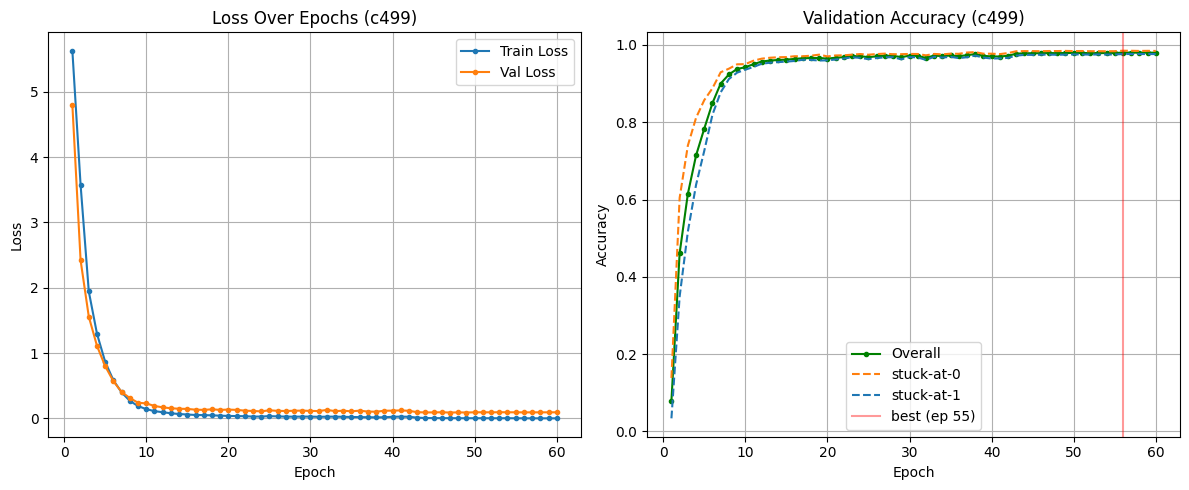

Best overall accuracy: 0.9801 at epoch 55

No prior LSTM baseline exists for c499 -- the FMCAD'25 paper stops at c1355.
Reference: corrected BiLSTM on c1355 = 0.9366 (paper-style LSTM there = 0.6963).
This run (c499, 501 classes with data): best = 0.9801 | sa0 = 0.9849 | sa1 = 0.9763


In [11]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(epochs, val_losses,   label='Val Loss',   marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Over Epochs (c499)'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Overall', color='green', marker='o', markersize=3)
plt.plot(epochs, val_sa0_accs,   label='stuck-at-0', color='tab:orange', linestyle='--', markersize=3)
plt.plot(epochs, val_sa1_accs,   label='stuck-at-1', color='tab:blue',   linestyle='--', markersize=3)
plt.axvline(best_epoch + 1, color='red', alpha=0.4, label=f'best (ep {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy (c499)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"Best overall accuracy: {best_acc:.4f} at epoch {best_epoch}")
sa0_best = val_sa0_accs[best_epoch]; sa1_best = val_sa1_accs[best_epoch]

print("\nNo prior LSTM baseline exists for c499 -- the FMCAD'25 paper stops at c1355.")
print("Reference: corrected BiLSTM on c1355 = 0.9366 (paper-style LSTM there = 0.6963).")
print(f"This run (c499, {classes_with_data:,} classes with data): best = {best_acc:.4f} | sa0 = {sa0_best:.4f} | sa1 = {sa1_best:.4f}")


## Tuning notes (c499)

- **Baseline to beat:** your May run of the paper-style LSTM on this same file reached **0.8156** overall (sa-0 0.8869, sa-1 0.7599). The raw (pre-dedup) data has a measured 88.10% ambiguity ceiling, but the deduped protocol used here can exceed it -- c1355 scored 0.9366 against its own 85.1% raw ceiling. This is the sparsest file of the study (median 64 samples/class, the c1355 regime).
- **Zero-sample classes:** 257 of 758 declared classes (34%) have zero samples after dedup -- second only to c1355. The task is effectively 501-way.
- **Let the LR cuts happen.** Across your finished runs, the plateau scheduler's first cut
  produced the biggest single-epoch jumps (c1908 +2.4 pts, c2670 +0.6, c1355 +3.3). The
  epoch budget here is sized so at least one cut occurs; if the best epoch lands within
  ~3 of the end, extend `EPOCHS` and rerun — the best checkpoint is kept either way.
- **Imbalance:** sa-1 : sa-0 = 1.27 : 1. Keep CE unweighted; per-type accuracies are
  tracked every epoch.
- **`!! DIVERGED` lines are normal** — guard restores best checkpoint, fresh Adam at half
  LR (floor 2e-4); one epoch lost per event.
- **Methodology note:** expanded samples sharing a parent pattern can land in both train
  and val — identical protocol to all baselines, optimistic vs. a pattern-level split.
- Expected runtime: ~10 s/epoch on an A100 (~10 min total).
